In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

Cargamos el dataset.

In [4]:
estudiantes = pd.read_csv('dataset_estudiantes.csv')
estudiantes.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


Realizamos una vista previa de los datos.

In [5]:
estudiantes.shape

(1000, 11)

In [6]:
estudiantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


In [7]:
estudiantes.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


In [8]:
estudiantes.describe(include = "str").T

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


Vemos los valores unicos y las frecuencias de las columnas categoricas.

In [9]:
columnas_categoricas = estudiantes.select_dtypes(include='str').columns

columnas_categoricas

Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')

In [10]:
for col in columnas_categoricas:
    print(estudiantes[col].value_counts())

nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64
tiene_tutor
No    597
Sí    403
Name: count, dtype: int64
horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64
estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64


Vemos cuantos nulos tenemos.

In [11]:
estudiantes.isna().sum()

horas_estudio_semanal          0
nota_anterior                  0
tasa_asistencia                0
horas_sueno                  150
edad                           0
nivel_dificultad               0
tiene_tutor                    0
horario_estudio_preferido    100
estilo_aprendizaje            50
nota_final                     0
aprobado                       0
dtype: int64

Hacemos la matriz de correlación.

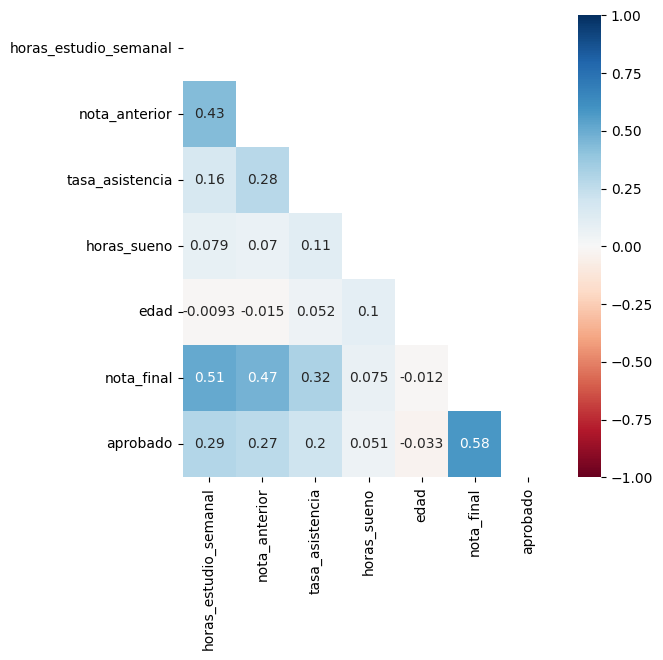

In [12]:
matriz = estudiantes.corr(numeric_only=True)

plt.figure(figsize=(6, 6))

sns.heatmap(matriz,
            annot=True,
            vmin=-1,
            vmax=1,
            mask = np.triu(matriz),
            cmap='RdBu')

plt.show()

Analizamos las inconsistencias.

In [ ]:
inconsistencias = []

# nota final >= 60 tiene que ser aprobado == 1 y al contrario.

# aprobados que figuran suspensos

mask = (estudiantes['nota_final'] >= 60) & (estudiantes['aprobado']==0)

for i in estudiantes.index[mask]:
    inconsistencias.append((i,'aprobado que figura suspenso'))

# suspensos que figuran aprobados

mask = (estudiantes['nota_final'] < 60) & (estudiantes['aprobado']==1)

for i in estudiantes.index[mask]:
    inconsistencias.append((i,'suspenso que figura aprobado'))

inconsistencias = pd.DataFrame(inconsistencias, columns=['Indice', 'Inconsistencia'])

inconsistencias.head()

# No hay inconsistencias

,Indice,Inconsistencia


Como no hemos hecho ninguna modificación seguiremos usando el mismo archivo csv.